# Urban Heat Island Detection

This notebook detects Urban Heat Island (UHI) regions using Landsat 9 satellite imagery.

The workflow includes:
1. Loading Landsat spectral bands
2. Calculating NDVI to identify vegetation
3. Estimating land surface temperature using thermal band
4. Detecting urban heat island zones based on temperature and vegetation conditions (Threshold based)
5. AI-based clustering using K-Means for heat risk analysis

---



## Dataset Description

This project uses Landsat 9 satellite imagery of Lucknow, Uttar Pradesh, India,
captured on 9 June 2025.

The following spectral bands are used:
- Band 4 (Red) – used for vegetation analysis
- Band 5 (Near Infrared) – used for NDVI calculation
- Band 10 (Thermal Infrared) – used to estimate land surface temperature

These bands are processed to compute NDVI and surface temperature, which are
then used to identify Urban Heat Island (UHI) regions in the study area.
___


In this project, two different approaches are used to identify Urban Heat Island (UHI) regions:

1. **Threshold-Based Method**
   - Uses statistical thresholds on land surface temperature and NDVI.
   - Areas with high temperature and low vegetation are classified as UHI zones.

2. **AI-Based Method (K-Means Clustering)**
   - Uses an unsupervised machine learning algorithm to cluster pixels
     based on NDVI and temperature values.
   - The clusters are interpreted as different levels of urban heat risk.

Both methods are implemented to compare traditional threshold analysis
with an AI-based clustering approach.
___

### Installing Required Libraries

The project uses:
- Rasterio for reading satellite raster images
- NumPy for numerical computation
- Matplotlib for visualization


In [7]:
!pip install rasterio numpy matplotlib

In [8]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [9]:
import os
os.listdir()

['.config',
 'LC09_L1TP_144041_20250609_20250609_02_T1_B4.TIF',
 'LC09_L1TP_144041_20250609_20250609_02_T1_B5.TIF',
 'LC09_L1TP_144041_20250609_20250609_02_T1_B10.TIF',
 'sample_data']

In [10]:
!find / -name "*B4.TIF" 2>/dev/null

/content/LC09_L1TP_144041_20250609_20250609_02_T1_B4.TIF


In [11]:
!find / -name "*B10.TIF" 2>/dev/null

/content/LC09_L1TP_144041_20250609_20250609_02_T1_B10.TIF


In [12]:
!find / -name "*MTL.txt" 2>/dev/null

In [13]:
!pwd
!ls /
!ls /content

/content
bin	 datalab  home	  lib32   media  proc		    root  srv  tools
boot	 dev	  kaggle  lib64   mnt	 python-apt	    run   sys  usr
content  etc	  lib	  libx32  opt	 python-apt.tar.xz  sbin  tmp  var
LC09_L1TP_144041_20250609_20250609_02_T1_B10.TIF
LC09_L1TP_144041_20250609_20250609_02_T1_B4.TIF
LC09_L1TP_144041_20250609_20250609_02_T1_B5.TIF
sample_data


In [14]:
!ls / | grep LC09

In [15]:
!find / -name "*B5.TIF" 2>/dev/null

/content/LC09_L1TP_144041_20250609_20250609_02_T1_B5.TIF


In [16]:
!mv /LC09_L1TP_144041_20250609_20250609_02_T1_B4.TIF /content/
!mv /LC09_L1TP_144041_20250609_20250609_02_T1_B10.TIF /content/
!mv /LC09_L1TP_144041_20250609_20250609_02_T1_MTL.txt /content/
!ls /content | grep LC09

mv: cannot stat '/LC09_L1TP_144041_20250609_20250609_02_T1_B4.TIF': No such file or directory
mv: cannot stat '/LC09_L1TP_144041_20250609_20250609_02_T1_B10.TIF': No such file or directory
mv: cannot stat '/LC09_L1TP_144041_20250609_20250609_02_T1_MTL.txt': No such file or directory
LC09_L1TP_144041_20250609_20250609_02_T1_B10.TIF
LC09_L1TP_144041_20250609_20250609_02_T1_B4.TIF
LC09_L1TP_144041_20250609_20250609_02_T1_B5.TIF


In [17]:
!pwd
!ls -l

/content
total 262468
-rw-r--r-- 1 root root 84556879 Mar 15 12:53 LC09_L1TP_144041_20250609_20250609_02_T1_B10.TIF
-rw-r--r-- 1 root root 91121700 Mar 15 12:53 LC09_L1TP_144041_20250609_20250609_02_T1_B4.TIF
-rw-r--r-- 1 root root 93077101 Mar 15 12:53 LC09_L1TP_144041_20250609_20250609_02_T1_B5.TIF
drwxr-xr-x 1 root root     4096 Jan 16 14:24 sample_data


In [18]:
!ls /content | grep B5
!ls /content

LC09_L1TP_144041_20250609_20250609_02_T1_B5.TIF
LC09_L1TP_144041_20250609_20250609_02_T1_B10.TIF
LC09_L1TP_144041_20250609_20250609_02_T1_B4.TIF
LC09_L1TP_144041_20250609_20250609_02_T1_B5.TIF
sample_data


In [19]:
!find / -name "*B5.TIF" 2>/dev/null

/content/LC09_L1TP_144041_20250609_20250609_02_T1_B5.TIF


## Accessing Landsat Band Files

The Landsat 9 band files used in this project correspond to imagery of
Lucknow, India captured on 9 June 2025.

Upload the following files from the repository directory:

- **Band 4 (Red)** – `LC09_L1TP_144041_20250609_20250609_02_T1_B4.TIF`
- **Band 5 (Near Infrared)** – `LC09_L1TP_144041_20250609_20250609_02_T1_B5.TIF`
- **Band 10 (Thermal Infrared)** – `LC09_L1TP_144041_20250609_20250609_02_T1_B10.TIF`

**NOTE**: If the band files are not available locally, download them from the
**Google Drive** link provided in the repository **README**.

These bands are used to compute NDVI and land surface temperature for
Urban Heat Island detection.

In [20]:
from google.colab import files
uploaded = files.upload()

Saving LC09_L1TP_144041_20250609_20250609_02_T1_B4.TIF to LC09_L1TP_144041_20250609_20250609_02_T1_B4 (1).TIF
Saving LC09_L1TP_144041_20250609_20250609_02_T1_B5.TIF to LC09_L1TP_144041_20250609_20250609_02_T1_B5 (1).TIF
Saving LC09_L1TP_144041_20250609_20250609_02_T1_B10.TIF to LC09_L1TP_144041_20250609_20250609_02_T1_B10 (1).TIF


In [21]:
import rasterio
import numpy as np

red_path = "/content/LC09_L1TP_144041_20250609_20250609_02_T1_B4.TIF"
nir_path = "/content/LC09_L1TP_144041_20250609_20250609_02_T1_B5.TIF"
thermal_path = "/content/LC09_L1TP_144041_20250609_20250609_02_T1_B10.TIF"

with rasterio.open(red_path) as src:
    red = src.read(1).astype(float)

with rasterio.open(nir_path) as src:
    nir = src.read(1).astype(float)

with rasterio.open(thermal_path) as src:
    thermal = src.read(1).astype(float)

print("Bands loaded successfully")
!ls /content | grep B4
!ls /content | grep B10

Bands loaded successfully
LC09_L1TP_144041_20250609_20250609_02_T1_B4 (1).TIF
LC09_L1TP_144041_20250609_20250609_02_T1_B4.TIF
LC09_L1TP_144041_20250609_20250609_02_T1_B10 (1).TIF
LC09_L1TP_144041_20250609_20250609_02_T1_B10.TIF


### NDVI Calculation

Normalized Difference Vegetation Index (NDVI) is used to identify vegetation.

Formula:

NDVI = (NIR - Red) / (NIR + Red)

Where:
- Band 5 = Near Infrared
- Band 4 = Red

Higher NDVI values indicate dense vegetation, while lower values indicate built-up or barren land.

In [22]:
ndvi = (nir - red) / (nir + red)

# Avoid divide-by-zero error
ndvi = np.where((nir + red) == 0, 0, ndvi)

print("NDVI calculated")
ndvi = np.divide(nir - red, nir + red,
                 out=np.zeros_like(nir),
                 where=(nir + red)!=0)

/tmp/ipykernel_7340/3128413522.py:1: RuntimeWarning: invalid value encountered in divide
  ndvi = (nir - red) / (nir + red)


NDVI calculated


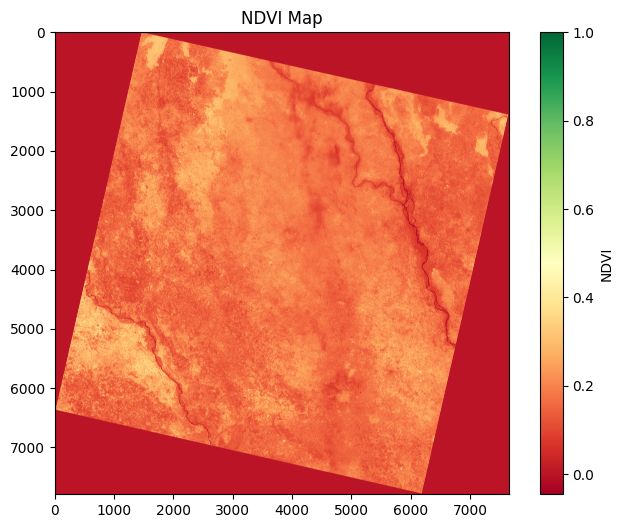

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(ndvi, cmap='RdYlGn')
plt.colorbar(label='NDVI')
plt.title("NDVI Map")
plt.show()

In [24]:
print("NDVI Min:", np.nanmin(ndvi))
print("NDVI Max:", np.nanmax(ndvi))
print("NDVI Mean:", np.nanmean(ndvi))

NDVI Min: -0.0454023670981277
NDVI Max: 1.0
NDVI Mean: 0.12587918774926066


In [25]:
ndvi = np.clip(ndvi, -1, 1)

In [26]:
!head -n 40 /LC09_L1TP_144041_20250609_20250609_02_T1_MTL.txt

head: cannot open '/LC09_L1TP_144041_20250609_20250609_02_T1_MTL.txt' for reading: No such file or directory


In [27]:
!grep -E "RADIANCE_MULT_BAND_10|RADIANCE_ADD_BAND_10|K1_CONSTANT_BAND_10|K2_CONSTANT_BAND_10" /LC09_L1TP_144041_20250609_20250609_02_T1_MTL.txt

grep: /LC09_L1TP_144041_20250609_20250609_02_T1_MTL.txt: No such file or directory


### Land Surface Temperature Estimation

Thermal band (Band 10) is used to estimate surface temperature.

Steps:
1. Convert digital number (DN) to spectral radiance
2. Convert radiance to brightness temperature
3. Convert temperature from Kelvin to Celsius

In [28]:
ML = 3.8000E-04
AL = 0.10000

radiance = ML * thermal + AL

print("Radiance calculated")

Radiance calculated


In [29]:
K1 = 799.0284
K2 = 1329.2405

bt = K2 / np.log((K1 / radiance) + 1)

print("Brightness Temperature calculated")
bt_celsius = bt - 273.15


Brightness Temperature calculated


In [30]:
print("Converted to Celsius")
print("Min Temp:", np.nanmin(bt_celsius))
print("Max Temp:", np.nanmax(bt_celsius))
print("Mean Temp:", np.nanmean(bt_celsius))

Converted to Celsius
Min Temp: -125.22826476768512
Max Temp: 46.76561045289526
Mean Temp: -18.431929047542862


In [31]:
# Mask invalid thermal pixels
thermal = np.where(thermal == 0, np.nan, thermal)

# Recalculate radiance
radiance = ML * thermal + AL

# Recalculate brightness temperature
bt = K2 / np.log((K1 / radiance) + 1)

# Convert to Celsius
bt_celsius = bt - 273.15

print("Recalculated temperature")

Recalculated temperature


In [32]:
print("Min Temp:", np.nanmin(bt_celsius))
print("Max Temp:", np.nanmax(bt_celsius))
print("Mean Temp:", np.nanmean(bt_celsius))

Min Temp: 12.75861968973635
Max Temp: 46.76561045289526
Mean Temp: 31.27451139061064


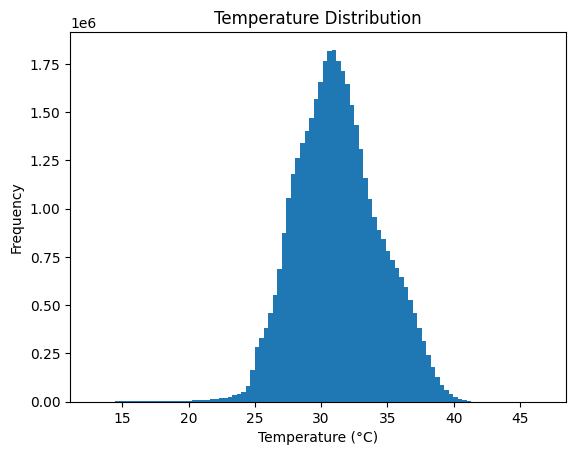

In [33]:
import matplotlib.pyplot as plt

plt.hist(bt_celsius.flatten(), bins=100)
plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

In [34]:
print("Pixels below 20°C:",
      np.sum(bt_celsius < 20))

print("Total pixels:",
      bt_celsius.size)
print("5th percentile:", np.nanpercentile(bt_celsius, 5))
print("95th percentile:", np.nanpercentile(bt_celsius, 95))

Pixels below 20°C: 46665
Total pixels: 59608941
5th percentile: 26.38154708437935
95th percentile: 36.840758190238034


In [35]:
mean_temp = np.nanmean(bt_celsius)
std_temp = np.nanstd(bt_celsius)

threshold = mean_temp + std_temp

print("Mean:", mean_temp)
print("Std Dev:", std_temp)
print("UHI Threshold:", threshold)

Mean: 31.27451139061064
Std Dev: 3.1796112605673383
UHI Threshold: 34.45412265117798



Urban heat islands are detected using two conditions:

1. Temperature higher than the threshold
2. Low vegetation (NDVI < 0.2)

Pixels satisfying both conditions are classified as UHI zones.

In [36]:
uhi = np.where(
    (bt_celsius > threshold) & (ndvi < 0.2),
    1,
    0
)

print("UHI map created")

UHI map created


### Visualization of Results

The following plots visualize:
- NDVI distribution
- Land surface temperature
- Detected Urban Heat Island regions

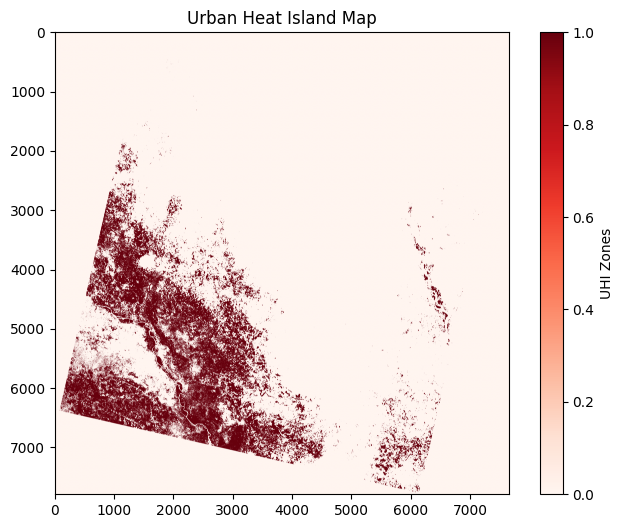

In [37]:
plt.figure(figsize=(8,6))
plt.imshow(uhi, cmap='Reds')
plt.title("Urban Heat Island Map")
plt.colorbar(label='UHI Zones')
plt.show()

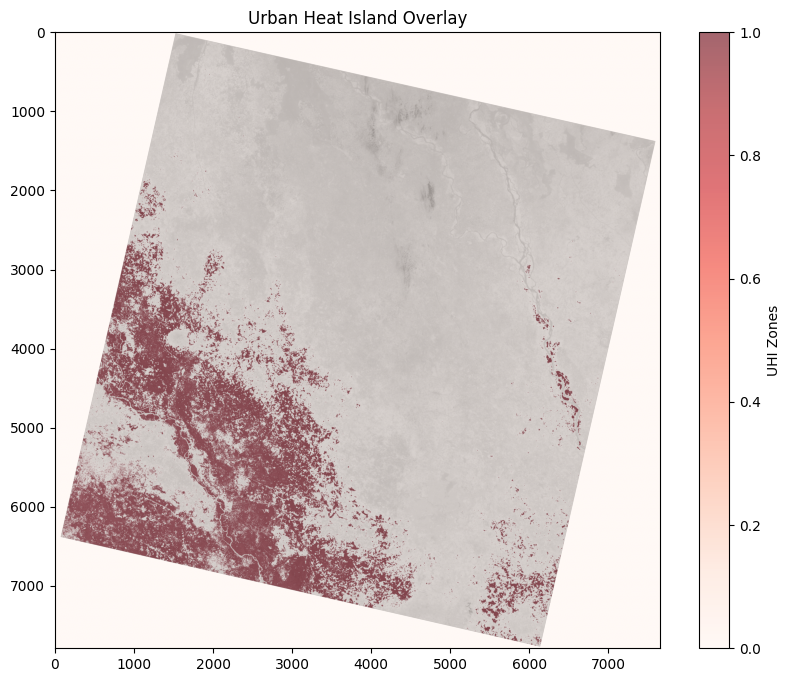

In [38]:
plt.figure(figsize=(10,8))

plt.imshow(bt_celsius, cmap='gray')
plt.imshow(uhi, cmap='Reds', alpha=0.6)

plt.title("Urban Heat Island Overlay")
plt.colorbar(label='UHI Zones')
plt.show()

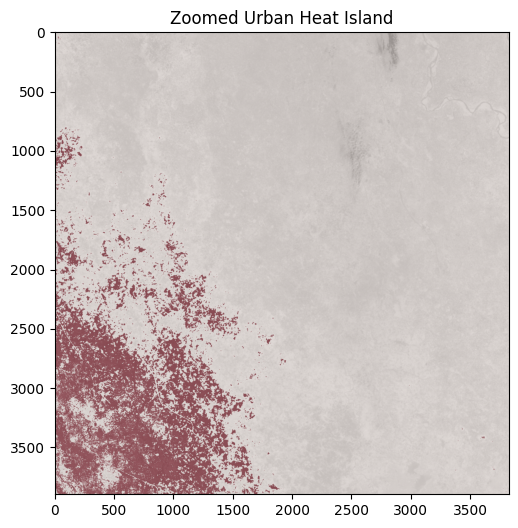

In [39]:
rows, cols = uhi.shape

# Crop center region (adjust fraction if needed)
crop = uhi[rows//4:3*rows//4, cols//4:3*cols//4]
crop_temp = bt_celsius[rows//4:3*rows//4, cols//4:3*cols//4]

plt.figure(figsize=(8,6))
plt.imshow(crop_temp, cmap='gray')
plt.imshow(crop, cmap='Reds', alpha=0.6)
plt.title("Zoomed Urban Heat Island")
plt.show()

In [40]:
uhi_pixels = np.sum(uhi == 1)
total_pixels = uhi.size

print("UHI Pixel Percentage:",
      (uhi_pixels / total_pixels) * 100)

UHI Pixel Percentage: 10.383395336615694


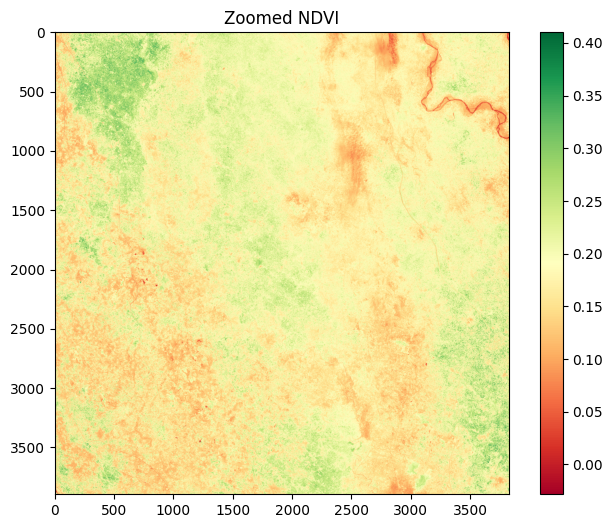

In [41]:
crop_ndvi = ndvi[rows//4:3*rows//4, cols//4:3*cols//4]

plt.figure(figsize=(8,6))
plt.imshow(crop_ndvi, cmap='RdYlGn')
plt.title("Zoomed NDVI")
plt.colorbar()
plt.show()

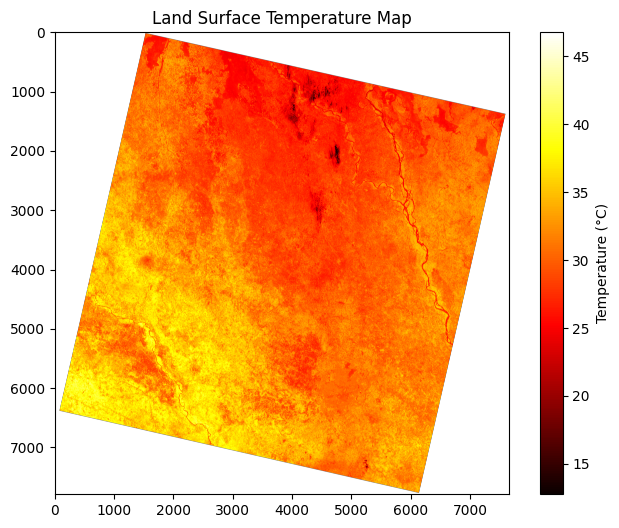

In [42]:
plt.figure(figsize=(8,6))
plt.imshow(bt_celsius, cmap='hot')
plt.colorbar(label='Temperature (°C)')
plt.title("Land Surface Temperature Map")
plt.show()

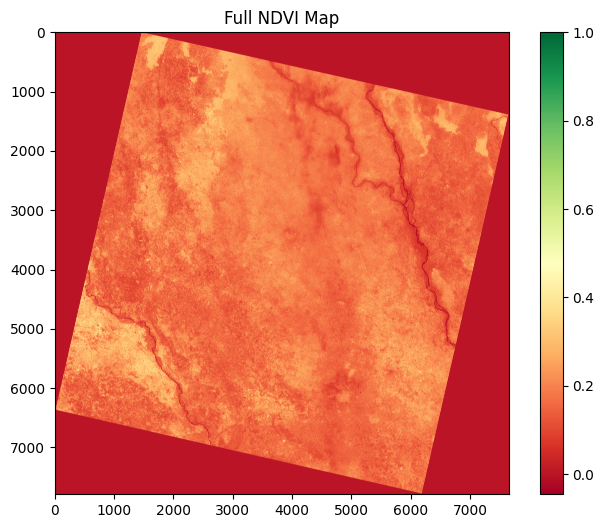

In [43]:
plt.figure(figsize=(8,6))
plt.imshow(ndvi, cmap='RdYlGn')
plt.title("Full NDVI Map")
plt.colorbar()
plt.show()

In [44]:
rows, cols = uhi.shape

north = uhi[:rows//2, :]
south = uhi[rows//2:, :]

north_percent = (np.sum(north == 1) / north.size) * 100
south_percent = (np.sum(south == 1) / south.size) * 100

print("North UHI %:", north_percent)
print("South UHI %:", south_percent)

North UHI %: 2.3328589028861626
South UHI %: 18.431865410890982


In [45]:
print("Standard Deviation:", np.nanstd(bt_celsius))

Standard Deviation: 3.1796112605673383


In [46]:
uhi_pixels = np.sum(uhi == 1)
total_pixels = uhi.size

print("Total UHI Pixels:", uhi_pixels)
print("Total Pixels:", total_pixels)
print("UHI Percentage:", (uhi_pixels / total_pixels) * 100)

Total UHI Pixels: 6189432
Total Pixels: 59608941
UHI Percentage: 10.383395336615694


In [47]:
print('ndvi' in globals())
print('bt_celsius' in globals())

True
True


## AI-Based Risk Analysis

In addition to threshold-based detection, this project also applies an
unsupervised machine learning technique (K-Means clustering).

The algorithm groups pixels based on:
- Land Surface Temperature (LST)
- NDVI values

These clusters represent different levels of urban heat risk, helping
identify potential Urban Heat Island regions automatically.

In [48]:
from sklearn.cluster import KMeans
import numpy as np

# Flatten arrays
temp_flat = bt_celsius.flatten()
ndvi_flat = ndvi.flatten()

# Remove NaN values
mask = ~np.isnan(temp_flat)
temp_clean = temp_flat[mask]
ndvi_clean = ndvi_flat[mask]

# Create feature matrix
X = np.column_stack((temp_clean, ndvi_clean))

print("Feature matrix shape:", X.shape)

Feature matrix shape: (40676700, 2)


In [49]:
# Take random sample of 200,000 pixels
sample_size = 200000

indices = np.random.choice(X.shape[0], sample_size, replace=False)
X_sample = X[indices]

print("Sample shape:", X_sample.shape)

Sample shape: (200000, 2)


In [50]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_sample)

print("Cluster centers:")
print(kmeans.cluster_centers_)

Cluster centers:
[[31.41466658  0.17975744]
 [27.71861499  0.20270311]
 [35.59545803  0.15478994]]


In [51]:
print("1st percentile:", np.nanpercentile(bt_celsius, 1))
print("5th percentile:", np.nanpercentile(bt_celsius, 5))
print("95th percentile:", np.nanpercentile(bt_celsius, 95))
print("99th percentile:", np.nanpercentile(bt_celsius, 99))

1st percentile: 24.720739643929107
5th percentile: 26.38154708437935
95th percentile: 36.840758190238034
99th percentile: 38.507919722359475


In [52]:
labels_full = np.full(temp_flat.shape, -1)

labels_full[mask] = kmeans.predict(X)

# Reshape back to image form
ai_risk_map = labels_full.reshape(bt_celsius.shape)

print("AI risk map created")

AI risk map created


In [53]:
for i, center in enumerate(kmeans.cluster_centers_):
    print(f"Cluster {i}: Temp = {center[0]:.2f}, NDVI = {center[1]:.3f}")

Cluster 0: Temp = 31.41, NDVI = 0.180
Cluster 1: Temp = 27.72, NDVI = 0.203
Cluster 2: Temp = 35.60, NDVI = 0.155


In [54]:
ai_ordered = np.zeros_like(ai_risk_map)

# Assign risk levels
ai_ordered[ai_risk_map == 0] = 1  # Low
ai_ordered[ai_risk_map == 2] = 2  # Moderate
ai_ordered[ai_risk_map == 1] = 3  # High

print("AI ordered risk map created")

AI ordered risk map created


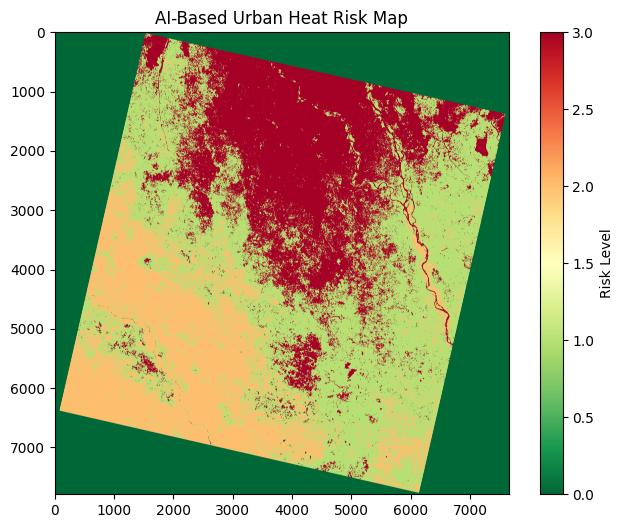

In [55]:
plt.figure(figsize=(8,6))
plt.imshow(ai_ordered, cmap='RdYlGn_r')
plt.title("AI-Based Urban Heat Risk Map")
plt.colorbar(label='Risk Level')
plt.show()

In [56]:
total = ai_ordered.size

low = np.sum(ai_ordered == 1) / total * 100
moderate = np.sum(ai_ordered == 2) / total * 100
high = np.sum(ai_ordered == 3) / total * 100

print("AI Low Risk %:", low)
print("AI Moderate Risk %:", moderate)
print("AI High Risk %:", high)

AI Low Risk %: 31.111206958030003
AI Moderate Risk %: 16.192502061058256
AI High Risk %: 20.93555059131146


In [57]:
mean_temp = np.nanmean(bt_celsius)
std_temp = np.nanstd(bt_celsius)

risk_map = np.zeros_like(bt_celsius)

risk_map[bt_celsius < mean_temp] = 1
risk_map[(bt_celsius >= mean_temp) &
         (bt_celsius <= mean_temp + std_temp)] = 2
risk_map[bt_celsius > mean_temp + std_temp] = 3

print("Threshold risk map rebuilt")

Threshold risk map rebuilt


In [ ]:
plt.figure(figsize=(8,6))
plt.imshow(risk_map, cmap='RdYlGn_r')
plt.title("Threshold-Based Urban Heat Risk Map")
plt.colorbar(label='Risk Level')
plt.show()


plt.figure(figsize=(8,6))
plt.imshow(ai_ordered, cmap='RdYlGn_r')
plt.title("AI-Based Urban Heat Risk Map (K-Means Clustering)")
plt.colorbar(label='Risk Level')
plt.show()